In [1]:
# import required libraries
import sys
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
python_path = sys.executable
spark = (
    SparkSession.builder
    .appName("bus_disruption_model_training")
    .config("spark.sql.shuffle.partitions","4")
    .config("spark.sql.session.timeZone","Europe/London")
    .config("spark.pyspark.python",python_path)
    .config("spark.pyspark.driver.python",python_path)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("spark session created")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/17 21:24:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


spark session created


In [2]:
# define project folders
current_folder = Path.cwd()
if current_folder.name == "notebooks":
    project_root = current_folder.parent
else:
    project_root = current_folder
model_csv_path = project_root / "data" / "processed" / "disruption_modelling_data_csv"
model_result_path = project_root / "data" / "processed" / "model_results"
prediction_output_path = project_root / "data" / "processed" / "model_predictions"
model_output_path = project_root / "models"
visualization_folder = project_root / "visualizations" / "model_evaluation"
model_result_path.mkdir(parents=True,exist_ok=True)
prediction_output_path.mkdir(parents=True,exist_ok=True)
model_output_path.mkdir(parents=True,exist_ok=True)
visualization_folder.mkdir(parents=True,exist_ok=True)
print("project root:",project_root)
print("modelling csv exists:",model_csv_path.exists())
print("model result folder:",model_result_path)
print("prediction folder:",prediction_output_path)
print("model folder:",model_output_path)
print("visualization folder:",visualization_folder)
if not model_csv_path.exists():
    raise FileNotFoundError("disruption modelling csv was not found")

project root: /Users/babitaadhikari/Desktop/bus-disruption-platform
modelling csv exists: True
model result folder: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/model_results
prediction folder: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/model_predictions
model folder: /Users/babitaadhikari/Desktop/bus-disruption-platform/models
visualization folder: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation


In [3]:
# load the modelling csv dataset
model_df = (
    spark.read
    .option("header",True)
    .option("inferSchema",True)
    .csv(str(model_csv_path))
)
model_df = model_df.repartition(4,"line_ref").cache()
model_rows = model_df.count()
print("modelling rows:",f"{model_rows:,}")
print("modelling columns:",len(model_df.columns))
print("modelling partitions:",model_df.rdd.getNumPartitions())

26/07/17 21:25:03 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 4:>                                                          (0 + 4) / 4]

modelling rows: 7,962
modelling columns: 47
modelling partitions: 4


In [4]:
# define model input features
feature_columns = [
    "observation_hour",
    "is_peak_hour",
    "is_weekend",
    "observed_vehicle_count",
    "observed_journey_count",
    "exact_match_rate",
    "fallback_match_rate",
    "data_quality_flag",
    "activity_ratio",
    "spacing_ratio",
    "activity_shortfall",
    "spacing_excess",
    "previous_vehicle_drop",
    "single_vehicle_flag"
]
# define identification and target columns
information_columns = [
    "event_snapshot_time",
    "next_snapshot_time",
    "line_ref",
    "published_line_name",
    "direction_ref",
    "model_eligible_flag",
    "target_severity_label",
    "target_severity_name"
]
# check that all required columns exist
required_columns = information_columns + feature_columns
missing_columns = [column_name for column_name in required_columns if column_name not in model_df.columns]
print("missing columns:",missing_columns)
if missing_columns:
    raise ValueError("required model columns are missing")
# keep rows suitable for model training
model_data_df = model_df.filter(F.col("model_eligible_flag") == 1).select(*required_columns)
# replace missing feature values with zero
fill_values = {column_name:0.0 for column_name in feature_columns}
model_data_df = (
    model_data_df
    .fillna(fill_values)
    .withColumn("label",F.col("target_severity_label").cast("double"))
    .filter(F.col("label").isin(0.0,1.0,2.0))
    .cache()
)
eligible_rows = model_data_df.count()
print("model eligible rows:",f"{eligible_rows:,}")
print("number of input features:",len(feature_columns))
print("model data partitions:",model_data_df.rdd.getNumPartitions())

missing columns: []


[Stage 11:>                                                         (0 + 4) / 4]

model eligible rows: 6,014
number of input features: 14
model data partitions: 4


In [5]:
# check missing values in model columns
check_columns = feature_columns + ["label"]
missing_summary_df = model_data_df.select([
    F.sum(F.when(F.col(column_name).isNull(),1).otherwise(0)).alias(column_name)
    for column_name in check_columns
])
missing_summary_df.show(truncate=False)
# display target class distribution
target_summary_df = model_data_df.groupBy("label","target_severity_name").count().orderBy("label")
target_summary_df.show(truncate=False)
target_class_count = target_summary_df.count()
print("number of target classes:",target_class_count)
if target_class_count < 3:
    raise ValueError("all three target classes are required")

+----------------+------------+----------+----------------------+----------------------+----------------+-------------------+-----------------+--------------+-------------+------------------+--------------+---------------------+-------------------+-----+
|observation_hour|is_peak_hour|is_weekend|observed_vehicle_count|observed_journey_count|exact_match_rate|fallback_match_rate|data_quality_flag|activity_ratio|spacing_ratio|activity_shortfall|spacing_excess|previous_vehicle_drop|single_vehicle_flag|label|
+----------------+------------+----------+----------------------+----------------------+----------------+-------------------+-----------------+--------------+-------------+------------------+--------------+---------------------+-------------------+-----+
|0               |0           |0         |0                     |0                     |0               |0                  |0                |0             |0            |0                 |0             |0                    |0      

In [6]:
# divide data into training and testing sets
training_df,testing_df = model_data_df.randomSplit([0.8,0.2],seed=42)
training_df = training_df.cache()
testing_df = testing_df.cache()
training_rows = training_df.count()
testing_rows = testing_df.count()
print("training rows:",f"{training_rows:,}")
print("testing rows:",f"{testing_rows:,}")
print("total split rows:",f"{training_rows + testing_rows:,}")
print("training class distribution")
training_df.groupBy("label").count().orderBy("label").show()
print("testing class distribution")
testing_df.groupBy("label").count().orderBy("label").show()
training_class_count = training_df.select("label").distinct().count()
testing_class_count = testing_df.select("label").distinct().count()
if training_class_count < 3:
    raise ValueError("training data does not contain all three classes")
if testing_class_count < 3:
    raise ValueError("testing data does not contain all three classes")

training rows: 4,861
testing rows: 1,153
total split rows: 6,014
training class distribution
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 3500|
|  1.0|  966|
|  2.0|  395|
+-----+-----+

testing class distribution
+-----+-----+
|label|count|
+-----+-----+
|  0.0|  806|
|  1.0|  244|
|  2.0|  103|
+-----+-----+



In [7]:
# collect training class counts
training_class_rows = training_df.groupBy("label").count().collect()
training_class_counts = {int(row["label"]):row["count"] for row in training_class_rows}
number_of_classes = len(training_class_counts)
# calculate balanced class weights
class_weights = {
    class_label:training_rows / (number_of_classes * class_count)
    for class_label,class_count in training_class_counts.items()
}
print("training class counts:",training_class_counts)
print("class weights:",class_weights)
# add class weights to training data
weighted_training_df = (
    training_df
    .withColumn(
        "class_weight",
        F.when(F.col("label") == 0.0,F.lit(class_weights[0]))
        .when(F.col("label") == 1.0,F.lit(class_weights[1]))
        .when(F.col("label") == 2.0,F.lit(class_weights[2]))
        .otherwise(F.lit(1.0))
    )
    .cache()
)
# add a normal weight to testing data
weighted_testing_df = testing_df.withColumn("class_weight",F.lit(1.0)).cache()
weighted_training_df.groupBy("label","class_weight").count().orderBy("label").show(truncate=False)

training class counts: {0: 3500, 1: 966, 2: 395}
class weights: {0: 0.46295238095238095, 1: 1.6773636991028296, 2: 4.10210970464135}
+-----+-------------------+-----+
|label|class_weight       |count|
+-----+-------------------+-----+
|0.0  |0.46295238095238095|3500 |
|1.0  |1.6773636991028296 |966  |
|2.0  |4.10210970464135   |395  |
+-----+-------------------+-----+



In [8]:
# define class names
class_names = {0:"low",1:"medium",2:"high"}
# create a list for all model results
model_results = []
# calculate classification evaluation metrics
def evaluate_predictions(model_name,predictions,training_seconds):
    evaluator = MulticlassClassificationEvaluator(labelCol="label",predictionCol="prediction")
    accuracy = evaluator.setMetricName("accuracy").evaluate(predictions)
    error_rate = 1.0 - accuracy
    weighted_precision = evaluator.setMetricName("weightedPrecision").evaluate(predictions)
    weighted_recall = evaluator.setMetricName("weightedRecall").evaluate(predictions)
    weighted_f1 = evaluator.setMetricName("f1").evaluate(predictions)
    confusion_rows = predictions.groupBy("label","prediction").count().collect()
    confusion_counts = {(int(row["label"]),int(row["prediction"])):row["count"] for row in confusion_rows}
    class_f1_values = []
    class_recall_values = {}
    for class_label in [0,1,2]:
        true_positive = confusion_counts.get((class_label,class_label),0)
        false_positive = sum(confusion_counts.get((other_label,class_label),0) for other_label in [0,1,2] if other_label != class_label)
        false_negative = sum(confusion_counts.get((class_label,other_label),0) for other_label in [0,1,2] if other_label != class_label)
        precision = true_positive / (true_positive + false_positive) if true_positive + false_positive > 0 else 0.0
        recall = true_positive / (true_positive + false_negative) if true_positive + false_negative > 0 else 0.0
        class_f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
        class_f1_values.append(class_f1)
        class_recall_values[class_label] = recall
    macro_f1 = sum(class_f1_values) / len(class_f1_values)
    return {
        "model":model_name,
        "accuracy":accuracy,
        "error_rate":error_rate,
        "weighted_precision":weighted_precision,
        "weighted_recall":weighted_recall,
        "weighted_f1":weighted_f1,
        "macro_f1":macro_f1,
        "high_severity_recall":class_recall_values[2],
        "training_seconds":training_seconds
    }
# create and save a confusion matrix
def save_confusion_matrix(predictions,title,file_name):
    confusion_pdf = predictions.select(F.col("label").cast("int").alias("actual"),F.col("prediction").cast("int").alias("predicted")).toPandas()
    confusion_table = pd.crosstab(confusion_pdf["actual"],confusion_pdf["predicted"]).reindex(index=[0,1,2],columns=[0,1,2],fill_value=0)
    plt.figure(figsize=(7,6))
    plt.imshow(confusion_table.values,aspect="auto")
    plt.colorbar()
    plt.xticks([0,1,2],["low","medium","high"])
    plt.yticks([0,1,2],["low","medium","high"])
    plt.xlabel("predicted severity")
    plt.ylabel("actual severity")
    plt.title(title)
    for row_index in range(3):
        for column_index in range(3):
            plt.text(column_index,row_index,int(confusion_table.iloc[row_index,column_index]),ha="center",va="center")
    plt.tight_layout()
    figure_path = visualization_folder / file_name
    plt.savefig(figure_path,dpi=300,bbox_inches="tight")
    print("saved:",figure_path)
    plt.show()
    plt.close()
    return figure_path

majority class number: 0
majority class name: low
baseline prediction rows: 1153
baseline results
{'model': 'majority baseline', 'accuracy': 0.6990459670424979, 'error_rate': 0.3009540329575021, 'weighted_precision': 0.48866526403838095, 'weighted_recall': 0.6990459670424979, 'weighted_f1': 0.5752231234673335, 'macro_f1': 0.27428960353922066, 'high_severity_recall': 0.0, 'training_seconds': 0.0}
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/00_majority_baseline_confusion_matrix.png


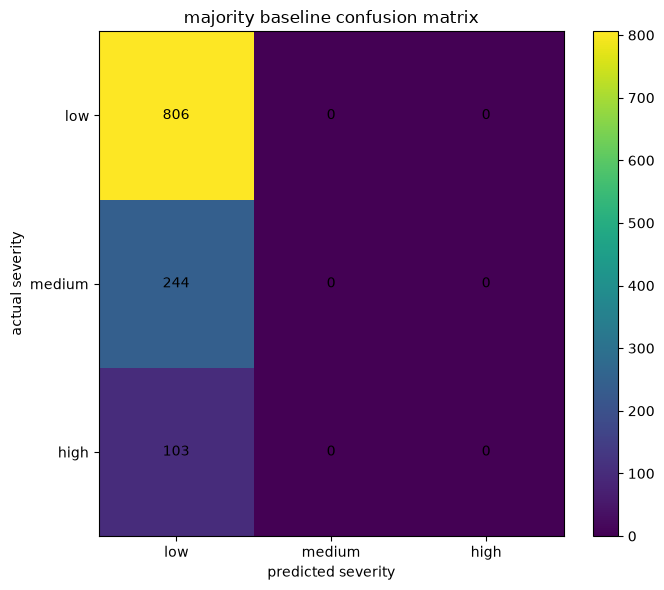

In [9]:
# find the largest training class
majority_class_row = training_df.groupBy("label").count().orderBy(F.desc("count")).first()
majority_label = int(majority_class_row["label"])
print("majority class number:",majority_label)
print("majority class name:",class_names[majority_label])
# predict the majority class for every testing row
baseline_predictions = weighted_testing_df.withColumn("prediction",F.lit(float(majority_label))).cache()
baseline_prediction_rows = baseline_predictions.count()
print("baseline prediction rows:",baseline_prediction_rows)
baseline_result = evaluate_predictions("majority baseline",baseline_predictions,0.0)
model_results.append(baseline_result)
print("baseline results")
print(baseline_result)
baseline_confusion_figure_path = save_confusion_matrix(
    baseline_predictions,
    "majority baseline confusion matrix",
    "00_majority_baseline_confusion_matrix.png"
)

26/07/17 21:26:37 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


logistic regression prediction rows: 1153
logistic regression training seconds: 10.807
logistic regression results
{'model': 'logistic regression', 'accuracy': 0.6227233304423244, 'error_rate': 0.3772766695576756, 'weighted_precision': 0.6734006007872192, 'weighted_recall': 0.6227233304423244, 'weighted_f1': 0.6423576137185862, 'macro_f1': 0.49429661325171614, 'high_severity_recall': 0.4563106796116505, 'training_seconds': 10.80696537499989}
+-----+----------+-------------------------------------------------------------+
|label|prediction|probability                                                  |
+-----+----------+-------------------------------------------------------------+
|0.0  |2.0       |[0.14857977571518038,0.2562664141877821,0.5951538100970376]  |
|0.0  |0.0       |[0.38980989863861887,0.23184845105999025,0.37834165030139105]|
|0.0  |2.0       |[0.30287317670021396,0.32293147227777863,0.3741953510220074] |
|0.0  |2.0       |[0.36957196024684164,0.20560661223532822,0.4248214

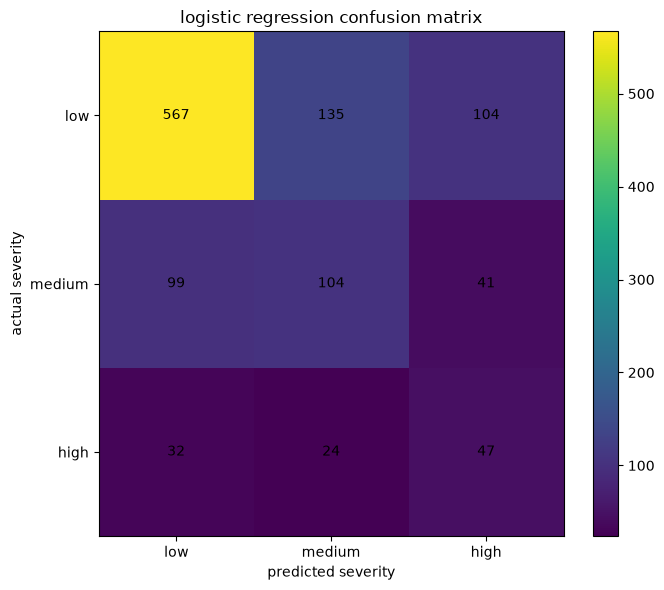

In [10]:
# create logistic regression pipeline
lr_assembler = VectorAssembler(inputCols=feature_columns,outputCol="features",handleInvalid="keep")
lr_scaler = StandardScaler(inputCol="features",outputCol="scaled_features",withMean=True,withStd=True)
lr_classifier = LogisticRegression(
    featuresCol="scaled_features",
    labelCol="label",
    weightCol="class_weight",
    family="multinomial",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0,
    standardization=False
)
lr_pipeline = Pipeline(stages=[lr_assembler,lr_scaler,lr_classifier])
# train logistic regression
lr_start_time = time.perf_counter()
lr_model = lr_pipeline.fit(weighted_training_df)
lr_training_seconds = time.perf_counter() - lr_start_time
# predict testing data
lr_predictions = lr_model.transform(weighted_testing_df).cache()
lr_prediction_rows = lr_predictions.count()
print("logistic regression prediction rows:",lr_prediction_rows)
print("logistic regression training seconds:",round(lr_training_seconds,3))
# evaluate logistic regression
lr_result = evaluate_predictions("logistic regression",lr_predictions,lr_training_seconds)
model_results.append(lr_result)
print("logistic regression results")
print(lr_result)
lr_predictions.select("label","prediction","probability").show(10,truncate=False)
lr_confusion_figure_path = save_confusion_matrix(
    lr_predictions,
    "logistic regression confusion matrix",
    "01_logistic_regression_confusion_matrix.png"
)

decision tree prediction rows: 1153
decision tree training seconds: 3.928
decision tree results
{'model': 'decision tree', 'accuracy': 0.6287944492627927, 'error_rate': 0.3712055507372073, 'weighted_precision': 0.7374569560094344, 'weighted_recall': 0.6287944492627927, 'weighted_f1': 0.6593634065292853, 'macro_f1': 0.5502434357452038, 'high_severity_recall': 0.7281553398058253, 'training_seconds': 3.9280322499998874}
+-----+----------+------------------------------------------------------------+
|label|prediction|probability                                                 |
+-----+----------+------------------------------------------------------------+
|0.0  |1.0       |[0.23693246852346428,0.7630675314765356,0.0]                |
|0.0  |0.0       |[1.0,0.0,0.0]                                               |
|0.0  |2.0       |[0.33715356127203644,0.01183119490725466,0.651015243820709] |
|0.0  |0.0       |[1.0,0.0,0.0]                                               |
|0.0  |1.0       |[

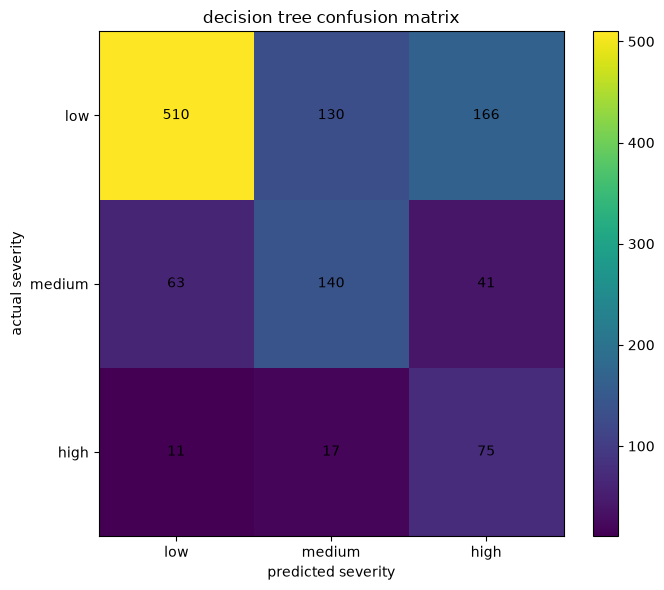

In [11]:
# create decision tree pipeline
dt_assembler = VectorAssembler(inputCols=feature_columns,outputCol="features",handleInvalid="keep")
dt_classifier = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    maxDepth=8,
    minInstancesPerNode=5,
    seed=42
)
dt_pipeline = Pipeline(stages=[dt_assembler,dt_classifier])
# train decision tree
dt_start_time = time.perf_counter()
dt_model = dt_pipeline.fit(weighted_training_df)
dt_training_seconds = time.perf_counter() - dt_start_time
# predict testing data
dt_predictions = dt_model.transform(weighted_testing_df).cache()
dt_prediction_rows = dt_predictions.count()
print("decision tree prediction rows:",dt_prediction_rows)
print("decision tree training seconds:",round(dt_training_seconds,3))
# evaluate decision tree
dt_result = evaluate_predictions("decision tree",dt_predictions,dt_training_seconds)
model_results.append(dt_result)
print("decision tree results")
print(dt_result)
dt_predictions.select("label","prediction","probability").show(10,truncate=False)
dt_confusion_figure_path = save_confusion_matrix(
    dt_predictions,
    "decision tree confusion matrix",
    "02_decision_tree_confusion_matrix.png"
)

26/07/17 21:27:01 WARN DAGScheduler: Broadcasting large task binary with size 1564.1 KiB
26/07/17 21:27:02 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/07/17 21:27:03 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB
26/07/17 21:27:05 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
26/07/17 21:27:08 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/07/17 21:27:09 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
                                                                                

random forest prediction rows: 1153
random forest training seconds: 10.443


26/07/17 21:27:09 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/07/17 21:27:10 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/07/17 21:27:10 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/07/17 21:27:11 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/07/17 21:27:11 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/07/17 21:27:12 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


random forest results
{'model': 'random forest', 'accuracy': 0.6964440589765828, 'error_rate': 0.3035559410234172, 'weighted_precision': 0.7507771940589396, 'weighted_recall': 0.6964440589765828, 'weighted_f1': 0.7135278560511402, 'macro_f1': 0.6085184425569131, 'high_severity_recall': 0.6796116504854369, 'training_seconds': 10.443374417000086}


26/07/17 21:27:12 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


+-----+----------+--------------------------------------------------------------+
|label|prediction|probability                                                   |
+-----+----------+--------------------------------------------------------------+
|0.0  |2.0       |[0.1919713461007229,0.34387358261591955,0.4641550712833575]   |
|0.0  |0.0       |[0.9687064631547605,0.015462636423166485,0.015830900422073024]|
|0.0  |2.0       |[0.4476647889927565,0.03185775483333711,0.5204774561739063]   |
|0.0  |0.0       |[0.9695160974502369,0.005607262820937111,0.024876639728825964]|
|0.0  |1.0       |[0.2282413094134575,0.6189045758954776,0.15285411469106494]   |
|0.0  |1.0       |[0.27386706830233654,0.4165747707504109,0.30955816094725264]  |
|0.0  |0.0       |[0.46835905444022996,0.1327741118126641,0.39886683374710585]  |
|0.0  |1.0       |[0.20732012254563653,0.6770404185623113,0.11563945889205214]  |
|0.0  |0.0       |[0.40717476043931855,0.28350306259590785,0.3093221769647735]  |
|0.0  |2.0      

26/07/17 21:27:12 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/03_random_forest_confusion_matrix.png


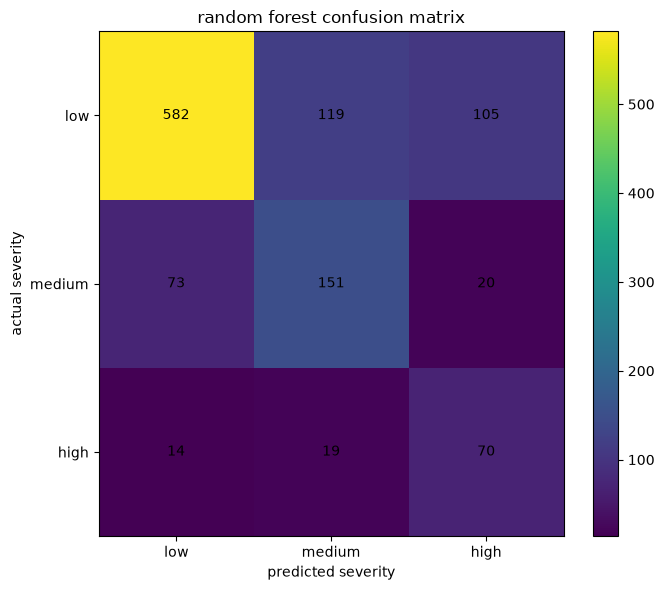

In [12]:
# create random forest pipeline
rf_assembler = VectorAssembler(inputCols=feature_columns,outputCol="features",handleInvalid="keep")
rf_classifier = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    numTrees=100,
    maxDepth=10,
    minInstancesPerNode=3,
    featureSubsetStrategy="sqrt",
    seed=42
)
rf_pipeline = Pipeline(stages=[rf_assembler,rf_classifier])
# train random forest
rf_start_time = time.perf_counter()
rf_model = rf_pipeline.fit(weighted_training_df)
rf_training_seconds = time.perf_counter() - rf_start_time
# predict testing data
rf_predictions = rf_model.transform(weighted_testing_df).cache()
rf_prediction_rows = rf_predictions.count()
print("random forest prediction rows:",rf_prediction_rows)
print("random forest training seconds:",round(rf_training_seconds,3))
# evaluate random forest
rf_result = evaluate_predictions("random forest",rf_predictions,rf_training_seconds)
model_results.append(rf_result)
print("random forest results")
print(rf_result)
rf_predictions.select("label","prediction","probability").show(10,truncate=False)
rf_confusion_figure_path = save_confusion_matrix(
    rf_predictions,
    "random forest confusion matrix",
    "03_random_forest_confusion_matrix.png"
)

                 model  accuracy  error_rate  weighted_precision  \
0        random forest    0.6964      0.3036              0.7508   
1        decision tree    0.6288      0.3712              0.7375   
2  logistic regression    0.6227      0.3773              0.6734   
3    majority baseline    0.6990      0.3010              0.4887   

   weighted_recall  weighted_f1  macro_f1  high_severity_recall  \
0           0.6964       0.7135    0.6085                0.6796   
1           0.6288       0.6594    0.5502                0.7282   
2           0.6227       0.6424    0.4943                0.4563   
3           0.6990       0.5752    0.2743                0.0000   

   training_seconds  
0           10.4434  
1            3.9280  
2           10.8070  
3            0.0000  
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/04_model_comparison.png


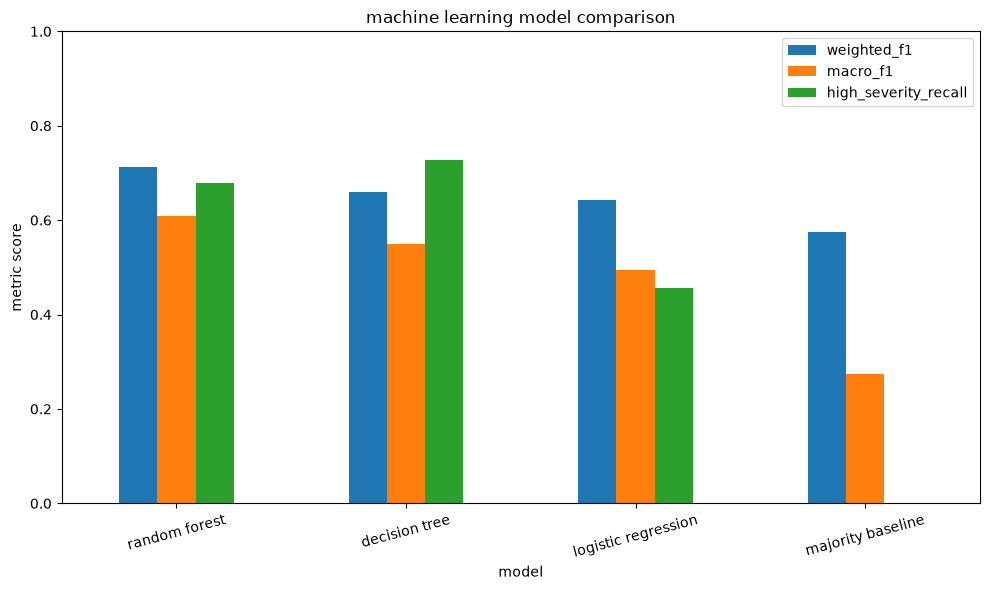

In [13]:
# create model comparison table
results_pdf = pd.DataFrame(model_results)[[
    "model",
    "accuracy",
    "error_rate",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "macro_f1",
    "high_severity_recall",
    "training_seconds"
]]
results_pdf = results_pdf.sort_values(by=["macro_f1","high_severity_recall","weighted_f1"],ascending=False).reset_index(drop=True)
print(results_pdf.round(4))
# create combined model comparison chart
comparison_chart_df = results_pdf.set_index("model")[["weighted_f1","macro_f1","high_severity_recall"]]
comparison_chart_df.plot(kind="bar",figsize=(10,6))
plt.title("machine learning model comparison")
plt.xlabel("model")
plt.ylabel("metric score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.tight_layout()
comparison_figure_path = visualization_folder / "04_model_comparison.png"
plt.savefig(comparison_figure_path,dpi=300,bbox_inches="tight")
print("saved:",comparison_figure_path)
plt.show()
plt.close()

In [14]:
# create a function for individual comparison charts
def save_metric_bar_chart(dataframe,column_name,title,y_label,file_name,include_baseline=True):
    chart_df = dataframe.copy()
    if not include_baseline:
        chart_df = chart_df[chart_df["model"] != "majority baseline"].copy()
    plt.figure(figsize=(9,6))
    bars = plt.bar(chart_df["model"],chart_df[column_name])
    plt.title(title)
    plt.xlabel("model")
    plt.ylabel(y_label)
    plt.xticks(rotation=15)
    for bar,value in zip(bars,chart_df[column_name]):
        plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),f"{value:.4f}",ha="center",va="bottom")
    plt.tight_layout()
    figure_path = visualization_folder / file_name
    plt.savefig(figure_path,dpi=300,bbox_inches="tight")
    print("saved:",figure_path)
    plt.show()
    plt.close()
    return figure_path

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/06_accuracy_comparison.png


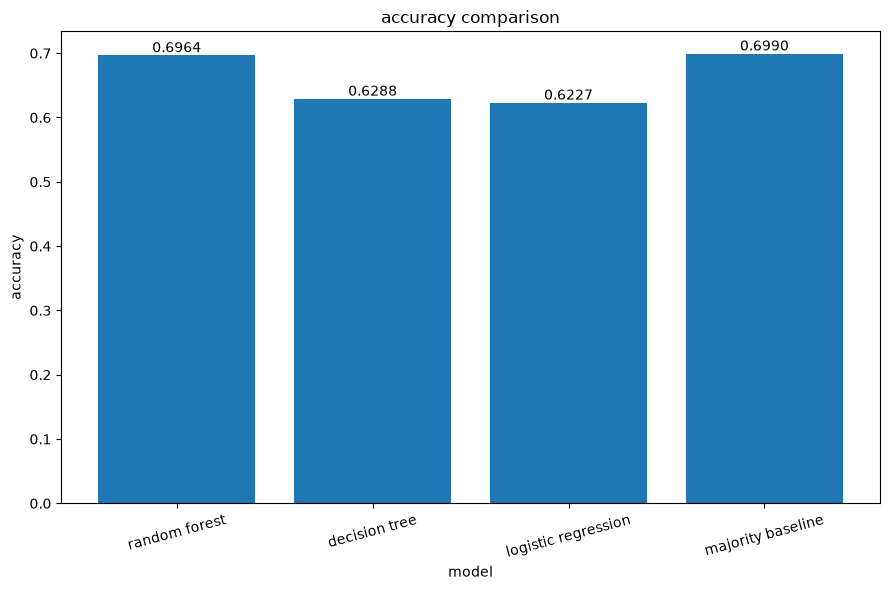

In [15]:
# create accuracy comparison chart
accuracy_figure_path = save_metric_bar_chart(
    results_pdf,
    "accuracy",
    "accuracy comparison",
    "accuracy",
    "06_accuracy_comparison.png"
)

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/07_classification_error_comparison.png


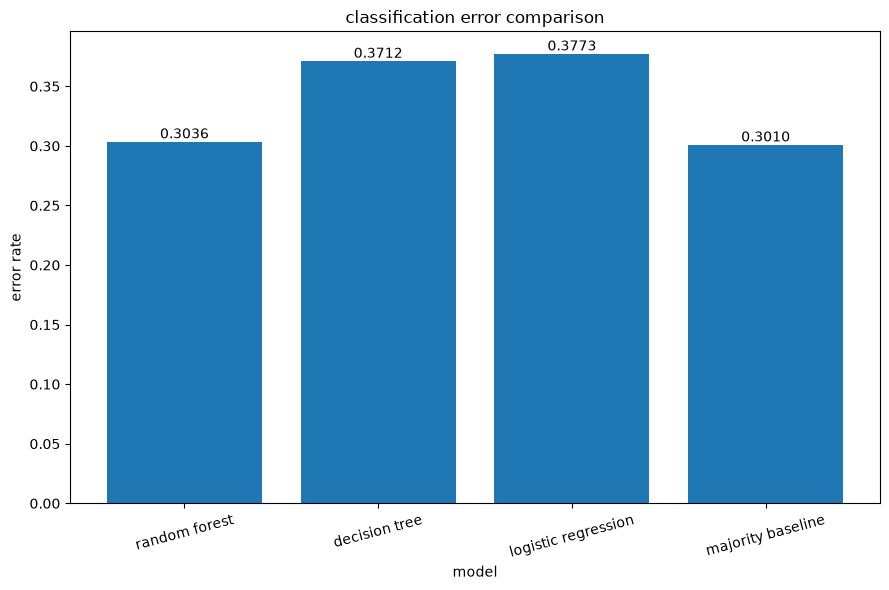

In [16]:
# create classification error comparison chart
error_figure_path = save_metric_bar_chart(
    results_pdf,
    "error_rate",
    "classification error comparison",
    "error rate",
    "07_classification_error_comparison.png"
)

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/08_weighted_precision_comparison.png


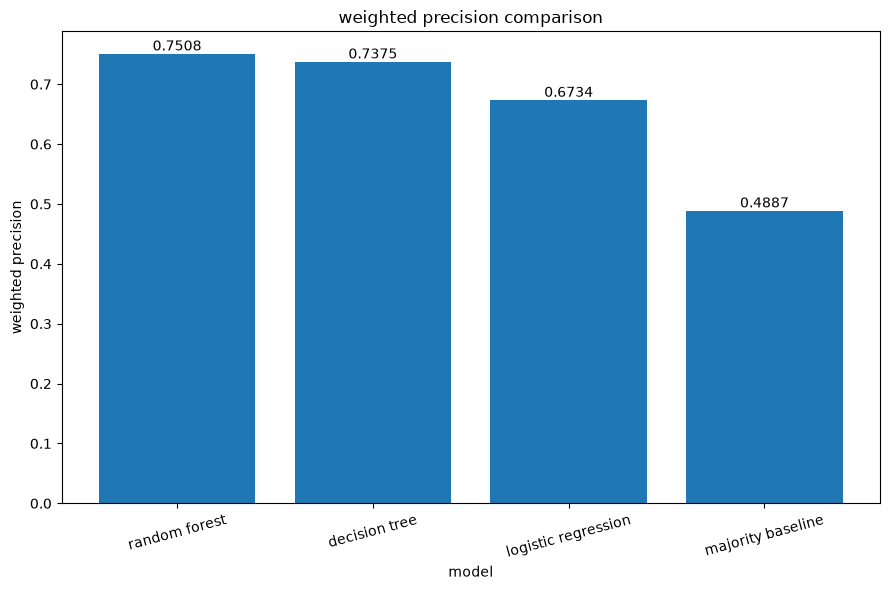

In [17]:
# create weighted precision comparison chart
precision_figure_path = save_metric_bar_chart(
    results_pdf,
    "weighted_precision",
    "weighted precision comparison",
    "weighted precision",
    "08_weighted_precision_comparison.png"
)

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/09_weighted_recall_comparison.png


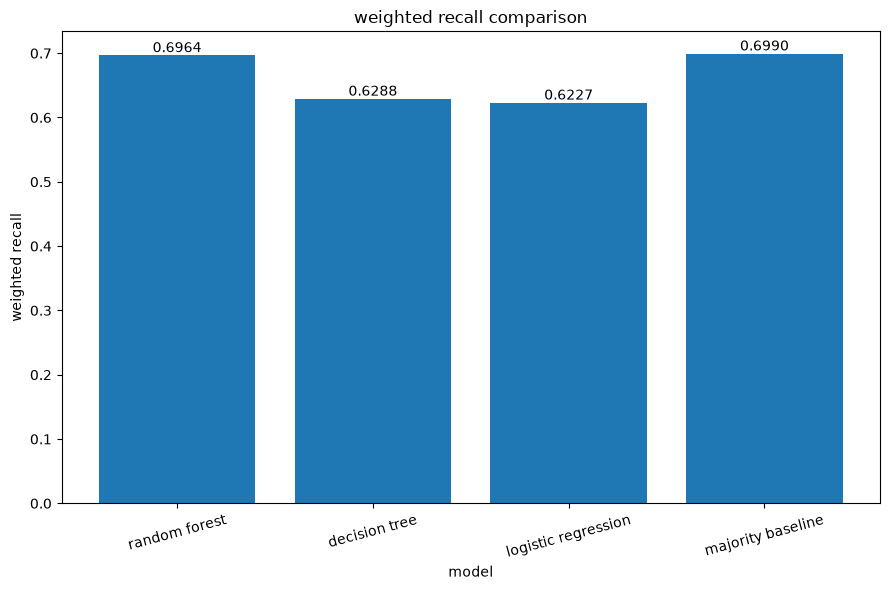

In [18]:
# create weighted recall comparison chart
recall_figure_path = save_metric_bar_chart(
    results_pdf,
    "weighted_recall",
    "weighted recall comparison",
    "weighted recall",
    "09_weighted_recall_comparison.png"
)

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/10_f1_comparison.png


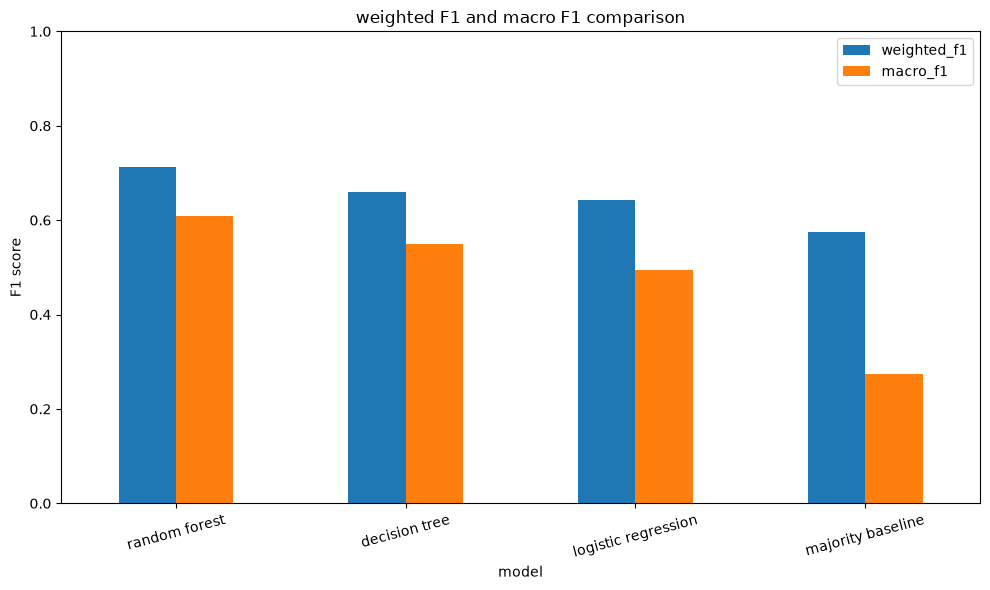

In [19]:
# create weighted F1 and macro F1 comparison chart
f1_chart_df = results_pdf.set_index("model")[["weighted_f1","macro_f1"]]
f1_chart_df.plot(kind="bar",figsize=(10,6))
plt.title("weighted F1 and macro F1 comparison")
plt.xlabel("model")
plt.ylabel("F1 score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.tight_layout()
f1_figure_path = visualization_folder / "10_f1_comparison.png"
plt.savefig(f1_figure_path,dpi=300,bbox_inches="tight")
print("saved:",f1_figure_path)
plt.show()
plt.close()

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/11_training_time_comparison.png


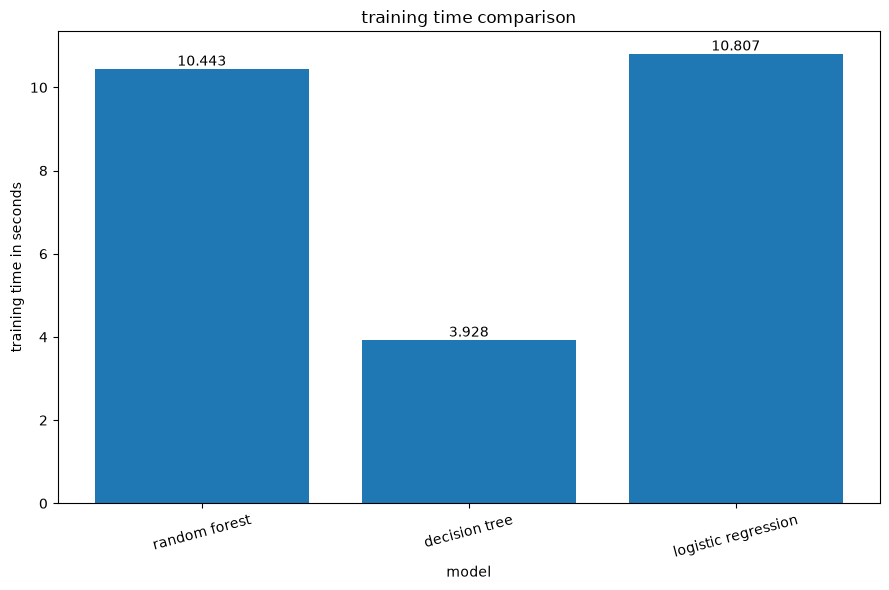

In [20]:
# keep only trained machine learning models
training_time_chart_df = results_pdf[results_pdf["model"] != "majority baseline"].copy()
# create training time comparison chart
plt.figure(figsize=(9,6))
training_time_bars = plt.bar(training_time_chart_df["model"],training_time_chart_df["training_seconds"])
plt.title("training time comparison")
plt.xlabel("model")
plt.ylabel("training time in seconds")
plt.xticks(rotation=15)
for bar,value in zip(training_time_bars,training_time_chart_df["training_seconds"]):
    plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),f"{value:.3f}",ha="center",va="bottom")
plt.tight_layout()
training_time_figure_path = visualization_folder / "11_training_time_comparison.png"
plt.savefig(training_time_figure_path,dpi=300,bbox_inches="tight")
print("saved:",training_time_figure_path)
plt.show()
plt.close()

                 model  weighted_f1  training_seconds  f1_per_second
0        random forest       0.7135           10.4434         0.0683
1        decision tree       0.6594            3.9280         0.1679
2  logistic regression       0.6424           10.8070         0.0594
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/12_model_efficiency_comparison.png


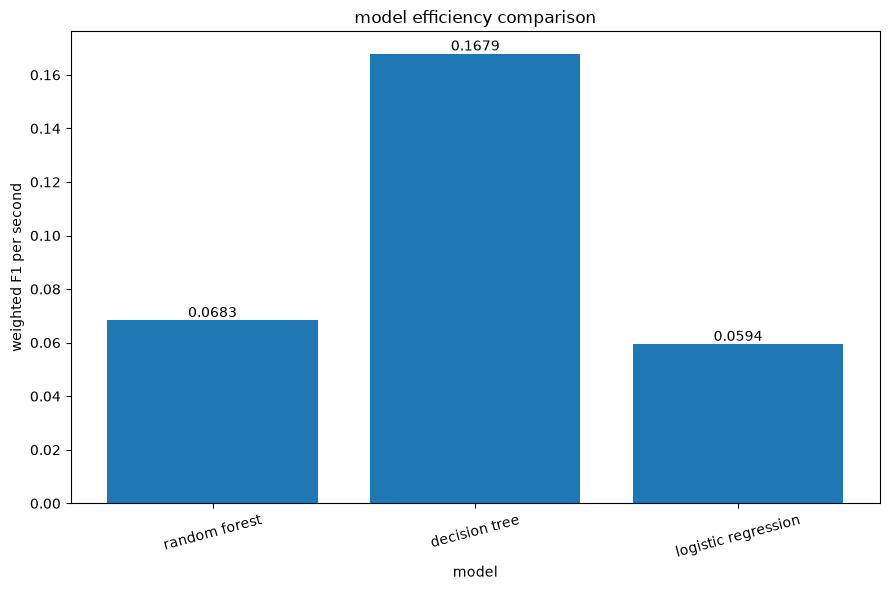

In [21]:
# calculate weighted F1 achieved per second
results_pdf["f1_per_second"] = results_pdf.apply(
    lambda row:row["weighted_f1"] / row["training_seconds"] if row["training_seconds"] > 0 else None,
    axis=1
)
# remove the baseline because it has no training time
efficiency_chart_df = results_pdf[results_pdf["model"] != "majority baseline"].copy()
print(efficiency_chart_df[["model","weighted_f1","training_seconds","f1_per_second"]].round(4))
# create model efficiency comparison chart
plt.figure(figsize=(9,6))
efficiency_bars = plt.bar(efficiency_chart_df["model"],efficiency_chart_df["f1_per_second"])
plt.title("model efficiency comparison")
plt.xlabel("model")
plt.ylabel("weighted F1 per second")
plt.xticks(rotation=15)
for bar,value in zip(efficiency_bars,efficiency_chart_df["f1_per_second"]):
    plt.text(bar.get_x() + bar.get_width() / 2,bar.get_height(),f"{value:.4f}",ha="center",va="bottom")
plt.tight_layout()
efficiency_figure_path = visualization_folder / "12_model_efficiency_comparison.png"
plt.savefig(efficiency_figure_path,dpi=300,bbox_inches="tight")
print("saved:",efficiency_figure_path)
plt.show()
plt.close()

                   feature  importance
0           activity_ratio    0.185496
1            spacing_ratio    0.139805
2   observed_journey_count    0.135893
3   observed_vehicle_count    0.122376
4       activity_shortfall    0.120575
5           spacing_excess    0.092084
6         observation_hour    0.061519
7    previous_vehicle_drop    0.033942
8      fallback_match_rate    0.031785
9         exact_match_rate    0.031292
10            is_peak_hour    0.020798
11     single_vehicle_flag    0.016928
12       data_quality_flag    0.007506
13              is_weekend    0.000000
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/05_random_forest_feature_importance.png


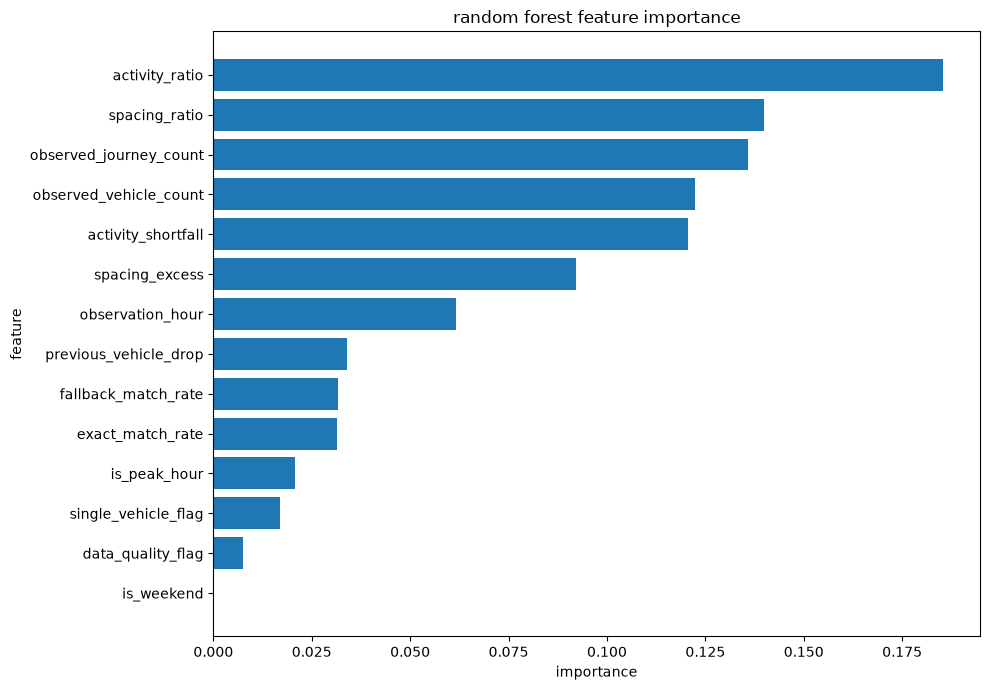

In [22]:
# get random forest feature importance
rf_classifier_model = rf_model.stages[-1]
rf_importance_values = rf_classifier_model.featureImportances.toArray()
importance_pdf = pd.DataFrame({"feature":feature_columns,"importance":rf_importance_values})
importance_pdf = importance_pdf.sort_values("importance",ascending=False).reset_index(drop=True)
print(importance_pdf)
# create feature importance chart
importance_chart_pdf = importance_pdf.sort_values("importance",ascending=True)
plt.figure(figsize=(10,7))
plt.barh(importance_chart_pdf["feature"],importance_chart_pdf["importance"])
plt.title("random forest feature importance")
plt.xlabel("importance")
plt.ylabel("feature")
plt.tight_layout()
importance_figure_path = visualization_folder / "05_random_forest_feature_importance.png"
plt.savefig(importance_figure_path,dpi=300,bbox_inches="tight")
print("saved:",importance_figure_path)
plt.show()
plt.close()

In [23]:
# connect model names to trained models
trained_models = {
    "logistic regression":lr_model,
    "decision tree":dt_model,
    "random forest":rf_model
}
# connect model names to prediction dataframes
prediction_dataframes = {
    "logistic regression":lr_predictions,
    "decision tree":dt_predictions,
    "random forest":rf_predictions
}
# remove the baseline before selecting the best trained model
trained_results_pdf = results_pdf[results_pdf["model"] != "majority baseline"].copy()
best_model_row = trained_results_pdf.sort_values(by=["macro_f1","high_severity_recall","weighted_f1"],ascending=False).iloc[0]
best_model_name = best_model_row["model"]
best_model = trained_models[best_model_name]
best_model_path = model_output_path / "best_disruption_classifier"
best_model.write().overwrite().save(str(best_model_path))
print("best model:",best_model_name)
print("best accuracy:",round(best_model_row["accuracy"],4))
print("best error rate:",round(best_model_row["error_rate"],4))
print("best macro F1:",round(best_model_row["macro_f1"],4))
print("best high severity recall:",round(best_model_row["high_severity_recall"],4))
print("best model saved:",best_model_path)

best model: random forest
best accuracy: 0.6964
best error rate: 0.3036
best macro F1: 0.6085
best high severity recall: 0.6796
best model saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/models/best_disruption_classifier


26/07/17 21:31:43 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


   class_number severity  precision  recall  f1_score  support
0             0      low     0.8700  0.7221    0.7892      806
1             1   medium     0.5225  0.6189    0.5666      244
2             2     high     0.3590  0.6796    0.4698      103
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/13_best_model_class_performance.png


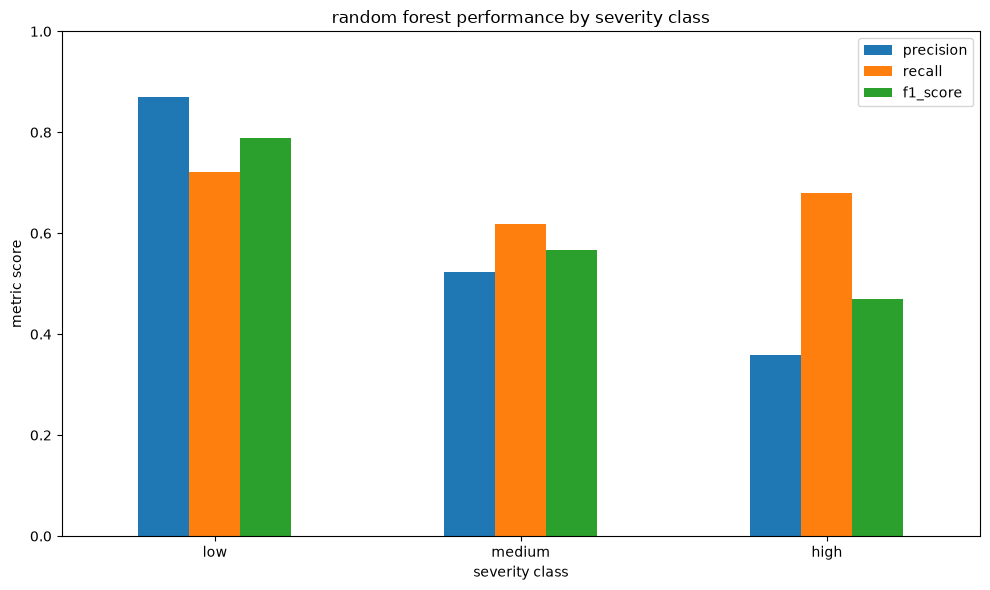

In [24]:
# select actual and predicted classes from the best model
best_class_predictions_pdf = prediction_dataframes[best_model_name].select("label","prediction").toPandas()
actual_class_values = best_class_predictions_pdf["label"].astype(int).to_numpy()
predicted_class_values = best_class_predictions_pdf["prediction"].astype(int).to_numpy()
# calculate precision recall F1 and support for each class
class_precision,class_recall,class_f1,class_support = precision_recall_fscore_support(
    actual_class_values,
    predicted_class_values,
    labels=[0,1,2],
    zero_division=0
)
best_class_metrics_pdf = pd.DataFrame({
    "class_number":[0,1,2],
    "severity":["low","medium","high"],
    "precision":class_precision,
    "recall":class_recall,
    "f1_score":class_f1,
    "support":class_support
})
print(best_class_metrics_pdf.round(4))
# create best model performance chart
best_class_chart_df = best_class_metrics_pdf.set_index("severity")[["precision","recall","f1_score"]]
best_class_chart_df.plot(kind="bar",figsize=(10,6))
plt.title(best_model_name + " performance by severity class")
plt.xlabel("severity class")
plt.ylabel("metric score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.tight_layout()
best_class_figure_path = visualization_folder / "13_best_model_class_performance.png"
plt.savefig(best_class_figure_path,dpi=300,bbox_inches="tight")
print("saved:",best_class_figure_path)
plt.show()
plt.close()

In [26]:
# convert a pyspark probability vector into a numpy array
def probability_vector_to_array(probability_value):
    if hasattr(probability_value,"toArray"):
        return probability_value.toArray()
    return np.array(probability_value)
# prepare actual classes and probabilities for ROC evaluation
def prepare_roc_data(predictions):
    roc_pdf = predictions.select("label","probability").toPandas()
    actual_labels = roc_pdf["label"].astype(int).to_numpy()
    actual_binary = label_binarize(actual_labels,classes=[0,1,2])
    probability_matrix = np.vstack(roc_pdf["probability"].apply(probability_vector_to_array).to_numpy())
    return actual_labels,actual_binary,probability_matrix

26/07/17 21:32:31 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/14_best_model_roc_curves.png


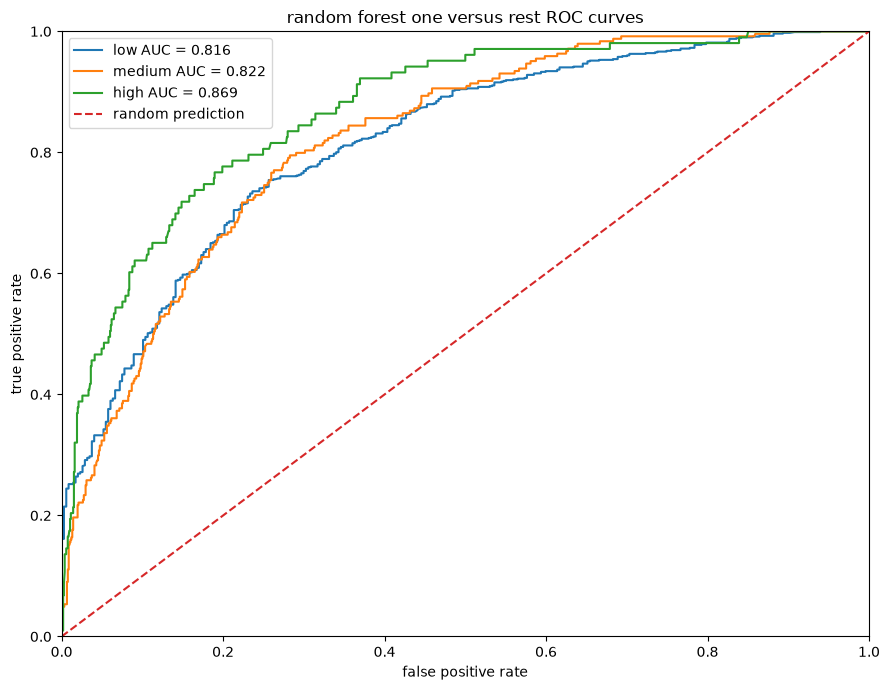

  severity  roc_auc
0      low   0.8163
1   medium   0.8221
2     high   0.8694


In [27]:
# prepare ROC data for the selected best model
best_actual_labels,best_actual_binary,best_probability_matrix = prepare_roc_data(prediction_dataframes[best_model_name])
# create one versus rest ROC curves
plt.figure(figsize=(9,7))
best_model_class_auc_rows = []
for class_index,class_name in enumerate(["low","medium","high"]):
    false_positive_rate,true_positive_rate,thresholds = roc_curve(best_actual_binary[:,class_index],best_probability_matrix[:,class_index])
    class_auc = auc(false_positive_rate,true_positive_rate)
    best_model_class_auc_rows.append({"severity":class_name,"roc_auc":class_auc})
    plt.plot(false_positive_rate,true_positive_rate,label=f"{class_name} AUC = {class_auc:.3f}")
plt.plot([0,1],[0,1],"--",label="random prediction")
plt.title(best_model_name + " one versus rest ROC curves")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.xlim(0,1)
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
best_model_roc_figure_path = visualization_folder / "14_best_model_roc_curves.png"
plt.savefig(best_model_roc_figure_path,dpi=300,bbox_inches="tight")
print("saved:",best_model_roc_figure_path)
plt.show()
plt.close()
best_model_class_auc_pdf = pd.DataFrame(best_model_class_auc_rows)
print(best_model_class_auc_pdf.round(4))

26/07/17 21:32:44 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


                 model  macro_roc_auc  weighted_roc_auc
0        random forest         0.8359            0.8223
1        decision tree         0.8017            0.7935
2  logistic regression         0.7173            0.7140
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation/15_roc_auc_comparison.png


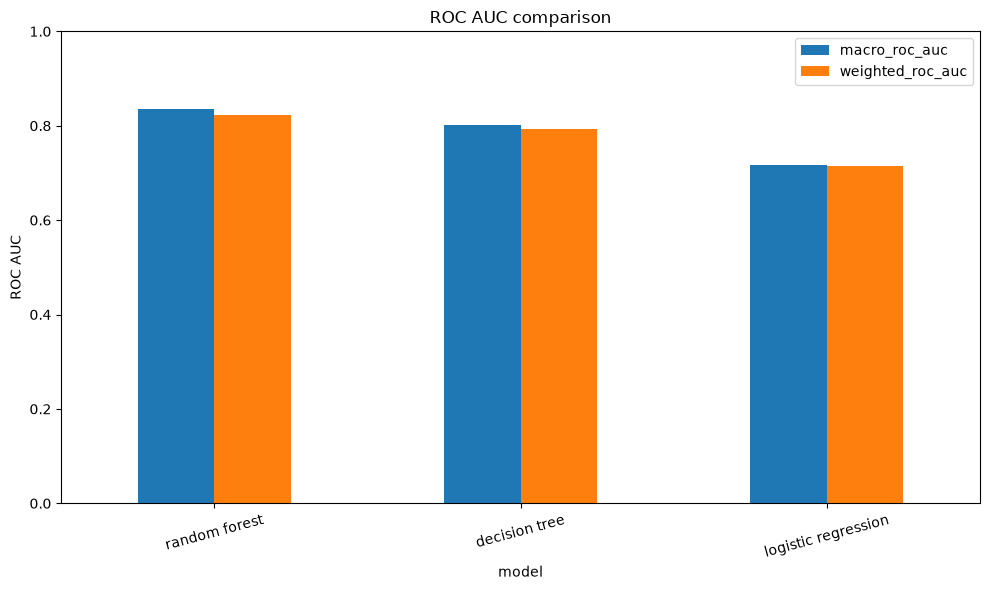

                 model  accuracy  error_rate  weighted_precision  \
0        random forest    0.6964      0.3036              0.7508   
1        decision tree    0.6288      0.3712              0.7375   
2  logistic regression    0.6227      0.3773              0.6734   
3    majority baseline    0.6990      0.3010              0.4887   

   weighted_recall  weighted_f1  macro_f1  high_severity_recall  \
0           0.6964       0.7135    0.6085                0.6796   
1           0.6288       0.6594    0.5502                0.7282   
2           0.6227       0.6424    0.4943                0.4563   
3           0.6990       0.5752    0.2743                0.0000   

   training_seconds  f1_per_second  macro_roc_auc  weighted_roc_auc  
0           10.4434         0.0683         0.8359            0.8223  
1            3.9280         0.1679         0.8017            0.7935  
2           10.8070         0.0594         0.7173            0.7140  
3            0.0000            NaN         

In [28]:
# calculate ROC AUC for each trained model
roc_auc_rows = []
for model_name,predictions in prediction_dataframes.items():
    actual_labels,actual_binary,probability_matrix = prepare_roc_data(predictions)
    macro_roc_auc = roc_auc_score(actual_labels,probability_matrix,average="macro",multi_class="ovr")
    weighted_roc_auc = roc_auc_score(actual_labels,probability_matrix,average="weighted",multi_class="ovr")
    roc_auc_rows.append({"model":model_name,"macro_roc_auc":macro_roc_auc,"weighted_roc_auc":weighted_roc_auc})
roc_auc_pdf = pd.DataFrame(roc_auc_rows).sort_values("macro_roc_auc",ascending=False).reset_index(drop=True)
print(roc_auc_pdf.round(4))
# create ROC AUC comparison chart
roc_auc_chart_df = roc_auc_pdf.set_index("model")[["macro_roc_auc","weighted_roc_auc"]]
roc_auc_chart_df.plot(kind="bar",figsize=(10,6))
plt.title("ROC AUC comparison")
plt.xlabel("model")
plt.ylabel("ROC AUC")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.tight_layout()
roc_auc_figure_path = visualization_folder / "15_roc_auc_comparison.png"
plt.savefig(roc_auc_figure_path,dpi=300,bbox_inches="tight")
print("saved:",roc_auc_figure_path)
plt.show()
plt.close()
# add ROC AUC results to the main comparison table
results_pdf = results_pdf.merge(roc_auc_pdf,on="model",how="left")
# update the best model row with all final metrics
best_model_row = results_pdf[results_pdf["model"] == best_model_name].iloc[0]
print(results_pdf.round(4))

In [29]:
# select predictions from the best model
best_predictions_df = prediction_dataframes[best_model_name]
# convert numerical classes into severity names
best_predictions_output_df = (
    best_predictions_df
    .withColumn("actual_severity",F.when(F.col("label") == 0.0,"low").when(F.col("label") == 1.0,"medium").otherwise("high"))
    .withColumn("predicted_severity",F.when(F.col("prediction") == 0.0,"low").when(F.col("prediction") == 1.0,"medium").otherwise("high"))
    .withColumn("probability_text",F.col("probability").cast("string"))
    .select(
        "event_snapshot_time",
        "next_snapshot_time",
        "line_ref",
        "published_line_name",
        "direction_ref",
        "actual_severity",
        "predicted_severity",
        "label",
        "prediction",
        "probability_text"
    )
)
best_prediction_path = prediction_output_path / "best_model_predictions"
(
    best_predictions_output_df
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header",True)
    .csv(str(best_prediction_path))
)
best_prediction_rows = best_predictions_output_df.count()
print("best prediction rows:",best_prediction_rows)
print("best predictions saved:",best_prediction_path)

26/07/17 21:33:11 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
26/07/17 21:33:12 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


best prediction rows: 1153
best predictions saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/model_predictions/best_model_predictions


In [30]:
# define model result files
model_comparison_file = model_result_path / "model_comparison.csv"
feature_importance_file = model_result_path / "random_forest_feature_importance.csv"
best_model_file = model_result_path / "best_model_summary.csv"
best_class_metrics_file = model_result_path / "best_model_class_metrics.csv"
roc_auc_file = model_result_path / "roc_auc_comparison.csv"
best_model_class_auc_file = model_result_path / "best_model_class_auc.csv"
# save model result tables
results_pdf.to_csv(model_comparison_file,index=False)
importance_pdf.to_csv(feature_importance_file,index=False)
pd.DataFrame([best_model_row.to_dict()]).to_csv(best_model_file,index=False)
best_class_metrics_pdf.to_csv(best_class_metrics_file,index=False)
roc_auc_pdf.to_csv(roc_auc_file,index=False)
best_model_class_auc_pdf.to_csv(best_model_class_auc_file,index=False)
print("saved:",model_comparison_file)
print("saved:",feature_importance_file)
print("saved:",best_model_file)
print("saved:",best_class_metrics_file)
print("saved:",roc_auc_file)
print("saved:",best_model_class_auc_file)

saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/model_results/model_comparison.csv
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/model_results/random_forest_feature_importance.csv
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/model_results/best_model_summary.csv
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/model_results/best_model_class_metrics.csv
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/model_results/roc_auc_comparison.csv
saved: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/model_results/best_model_class_auc.csv


In [31]:
# display example predictions
print("selected best model:",best_model_name)
best_predictions_output_df.show(20,truncate=False)
# count correct and incorrect predictions
prediction_check_df = (
    best_predictions_output_df
    .withColumn("prediction_status",F.when(F.col("label") == F.col("prediction"),"correct").otherwise("incorrect"))
    .groupBy("prediction_status")
    .count()
)
prediction_check_df.show()

selected best model: random forest


26/07/17 21:33:31 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


+-----------------------+-----------------------+--------+-------------------+-------------+---------------+------------------+-----+----------+--------------------------------------------------------------+
|event_snapshot_time    |next_snapshot_time     |line_ref|published_line_name|direction_ref|actual_severity|predicted_severity|label|prediction|probability_text                                              |
+-----------------------+-----------------------+--------+-------------------+-------------+---------------+------------------+-----+----------+--------------------------------------------------------------+
|2026-07-14 16:30:28.485|2026-07-14 17:30:37.087|10A     |10A                |inbound      |low            |high              |0.0  |2.0       |[0.1919713461007229,0.34387358261591955,0.4641550712833575]   |
|2026-07-14 16:30:28.485|2026-07-14 17:30:37.087|21A     |21A                |inbound      |low            |low               |0.0  |0.0       |[0.9687064631547605,0.01

26/07/17 21:33:32 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


+-----------------+-----+
|prediction_status|count|
+-----------------+-----+
|          correct|  803|
|        incorrect|  350|
+-----------------+-----+



26/07/17 21:33:32 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB


In [32]:
# display spark ui address
spark_ui_url = spark.sparkContext.uiWebUrl
print("spark ui url:",spark_ui_url)


spark ui url: http://192.168.1.2:4040


In [34]:
# define required output paths
required_output_paths = [
    best_model_path,
    best_prediction_path,
    model_comparison_file,
    feature_importance_file,
    best_model_file,
    best_class_metrics_file,
    roc_auc_file,
    best_model_class_auc_file,
    baseline_confusion_figure_path,
    lr_confusion_figure_path,
    dt_confusion_figure_path,
    rf_confusion_figure_path,
    comparison_figure_path,
    importance_figure_path,
    accuracy_figure_path,
    error_figure_path,
    precision_figure_path,
    recall_figure_path,
    f1_figure_path,
    training_time_figure_path,
    efficiency_figure_path,
    best_class_figure_path,
    best_model_roc_figure_path,
    roc_auc_figure_path
]
# find missing outputs
missing_output_paths = [str(output_path) for output_path in required_output_paths if not output_path.exists()]
print("missing output paths:",missing_output_paths)
if missing_output_paths:
    raise ValueError("some model outputs are missing")
if len(model_results) < 4:
    raise ValueError("fewer than four model approaches were evaluated")
print("model training and evaluation completed successfully")
print("machine learning models trained: 3")
print("baseline approaches included: 1")
print("total approaches compared:",len(model_results))
print("best model:",best_model_name)
print("testing rows:",f"{testing_rows:,}")
print("results saved in:",model_result_path)
print("predictions saved in:",prediction_output_path)
print("visualizations saved in:",visualization_folder)


missing output paths: []
model training and evaluation completed successfully
machine learning models trained: 3
baseline approaches included: 1
total approaches compared: 4
best model: random forest
testing rows: 1,153
results saved in: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/model_results
predictions saved in: /Users/babitaadhikari/Desktop/bus-disruption-platform/data/processed/model_predictions
visualizations saved in: /Users/babitaadhikari/Desktop/bus-disruption-platform/visualizations/model_evaluation
